In [3]:
# =========================================================
# Lightweight Alignment of Vision-Language Representations
# via 1D U-Net Residual Embedding Denoising (CLIP)
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1️Define lightweight 1D U-Net Residual Denoiser
# =========================================================

class UNet1DResidualDenoiser(nn.Module):
    """
    1D U-Net residual denoiser for CLIP embeddings.
    Formula: x_denoised = x_noisy - UNet1D(x_noisy - x_clean)
    """
    def __init__(self, embedding_dim=512, hidden_dim=1024):
        super().__init__()

        # Encoder
        self.enc1 = nn.Conv1d(embedding_dim, hidden_dim, kernel_size=1)
        self.enc2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)

        # Decoder
        self.dec1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)
        self.dec2 = nn.Conv1d(hidden_dim, embedding_dim, kernel_size=1)

        self.act = nn.ReLU()

    def forward(self, x_noisy, x_clean):
        # Compute residual noise
        residual = x_noisy - x_clean          # ε = x_noisy - x_clean
        residual = residual.unsqueeze(-1)     # [batch, embedding_dim, 1] for Conv1D

        # Encoder
        e1 = self.act(self.enc1(residual))
        e2 = self.act(self.enc2(e1))

        # Decoder with skip connection
        d1 = self.act(self.dec1(e2) + e1)
        d2 = self.dec2(d1).squeeze(-1)        # [batch, embedding_dim]

        # Residual subtraction
        x_denoised = x_noisy - d2
        return x_denoised

# =========================================================
# 2️⃣ Helper: Add Gaussian noise to embeddings
# =========================================================

def add_noise(embeddings, noise_std=0.2):
    return embeddings + torch.randn_like(embeddings) * noise_std

# =========================================================
# 3️⃣ Load dataset (small subset for demo)
# =========================================================

dataset = load_dataset("SKyu/my-image-captioning-dataset")
train_dataset = dataset["train"].select(range(2000, 3000))
val_dataset = dataset["train"].select(range(1, 1000))

def transformFn(batch):
    images = [item["image"] for item in batch]
    captions = [item["prompt"] for item in batch]
    return images, captions

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=transformFn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=transformFn)

# =========================================================
# 4️⃣ Load frozen CLIP model
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

# Freeze CLIP parameters
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

# =========================================================
# 5️⃣ Initialize 1D U-Net denoiser
# =========================================================

denoiser = UNet1DResidualDenoiser(embedding_dim=512, hidden_dim=1024).to(device)
optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# =========================================================
# 6️⃣ Training loop
# =========================================================

num_epochs = 10

for epoch in range(num_epochs):
    denoiser.train()
    epoch_loss = 0
    for images, captions in train_loader:
        # Prepare inputs
        inputs = processor(text=captions, images=images, return_tensors="pt",
                           padding=True, truncation=True, max_length=77).to(device)

        with torch.no_grad():
            # Get normalized CLIP embeddings
            img_embeds = F.normalize(clip_model.get_image_features(inputs["pixel_values"]), dim=-1)
            text_inputs = {k: v for k, v in inputs.items() if k in ["input_ids", "attention_mask"]}
            txt_embeds = F.normalize(clip_model.get_text_features(**text_inputs), dim=-1)

        # Add noise
        noisy_img = add_noise(img_embeds)
        noisy_txt = add_noise(txt_embeds)

        # Denoiser forward
        denoised_img = denoiser(noisy_img, img_embeds)
        denoised_txt = denoiser(noisy_txt, txt_embeds)

        # Loss with optional weighting λ1, λ2
        λ1, λ2 = 1.0, 1.0
        loss = λ1 * criterion(denoised_img, img_embeds) + λ2 * criterion(denoised_txt, txt_embeds)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_loss:.6f}")

print("✅ Residual denoiser training complete!")

# =========================================================
# Embedding extraction functions
# =========================================================

def get_raw_embeddings(images, captions):
    clip_model.eval()
    with torch.no_grad():
        inputs = processor(text=captions, images=images, return_tensors="pt",
                           padding=True, truncation=True, max_length=77).to(device)
        img_embeds = F.normalize(clip_model.get_image_features(inputs["pixel_values"]), dim=-1)
        text_inputs = {k: v for k, v in inputs.items() if k in ["input_ids", "attention_mask"]}
        txt_embeds = F.normalize(clip_model.get_text_features(**text_inputs), dim=-1)
    return img_embeds, txt_embeds

def get_denoised_embeddings(images, captions):
    denoiser.eval()
    img_embeds, txt_embeds = get_raw_embeddings(images, captions)
    denoised_img = F.normalize(denoiser(img_embeds, img_embeds), dim=-1)
    denoised_txt = F.normalize(denoiser(txt_embeds, txt_embeds), dim=-1)
    return denoised_img, denoised_txt

# =========================================================
# Evaluation function (Recall@K)
# =========================================================

def evaluate(loader, use_denoiser=False):
    recall_at_1, recall_at_3, recall_at_5, total = 0, 0, 0, 0

    for images, captions in loader:
        if use_denoiser:
            img_embeds, txt_embeds = get_denoised_embeddings(images, captions)
        else:
            img_embeds, txt_embeds = get_raw_embeddings(images, captions)

        sim_matrix = torch.matmul(img_embeds, txt_embeds.T)
        for i in range(sim_matrix.size(0)):
            scores = sim_matrix[i]
            top1 = scores.topk(min(1, scores.size(0))).indices[0].item()
            top3 = scores.topk(min(3, scores.size(0))).indices.tolist()
            top5 = scores.topk(min(5, scores.size(0))).indices.tolist()
            true_id = i
            if top1 == true_id:
                recall_at_1 += 1
            if true_id in top3:
                recall_at_3 += 1
            if true_id in top5:
                recall_at_5 += 1
            total += 1

    return {
        "Recall@1": recall_at_1 / total * 100,
        "Recall@3": recall_at_3 / total * 100,
        "Recall@5": recall_at_5 / total * 100
    }

# =========================================================
# Compare raw vs denoised embeddings
# =========================================================

raw_recalls = evaluate(val_loader, use_denoiser=False)
denoised_recalls = evaluate(val_loader, use_denoiser=True)

print("📌 CLIP embeddings (raw):", raw_recalls)
print("📌 Residual denoised embeddings (1D U-Net):", denoised_recalls)

# =========================================================
#  Plot embedding similarity (cosine)
# =========================================================

def compute_alignment(img_emb, txt_emb):
    sims = F.cosine_similarity(img_emb, txt_emb)
    return sims.mean().item()

images, captions = next(iter(val_loader))
raw_img, raw_txt = get_raw_embeddings(images, captions)
denoised_img, denoised_txt = get_denoised_embeddings(images, captions)

print(f"Raw embeddings alignment (cosine): {compute_alignment(raw_img, raw_txt):.4f}")
print(f"Denoised embeddings alignment (cosine): {compute_alignment(denoised_img, denoised_txt):.4f}")


Using device: cuda
Epoch 1/10, Avg Loss: 0.082043
Epoch 2/10, Avg Loss: 0.079430
Epoch 3/10, Avg Loss: 0.077306
Epoch 4/10, Avg Loss: 0.074615
Epoch 5/10, Avg Loss: 0.071751
Epoch 6/10, Avg Loss: 0.068160
Epoch 7/10, Avg Loss: 0.064744
Epoch 8/10, Avg Loss: 0.061345
Epoch 9/10, Avg Loss: 0.058295
Epoch 10/10, Avg Loss: 0.054961
✅ Residual denoiser training complete!
📌 CLIP embeddings (raw): {'Recall@1': 40.94094094094094, 'Recall@3': 66.46646646646647, 'Recall@5': 76.87687687687688}
📌 Residual denoised embeddings (1D U-Net): {'Recall@1': 39.83983983983984, 'Recall@3': 66.26626626626627, 'Recall@5': 77.87787787787788}
Raw embeddings alignment (cosine): 0.2973
Denoised embeddings alignment (cosine): 0.3776


In [4]:
# =========================================================
# Research-ready: Cross-modal CLIP Embedding Denoiser
# =========================================================


# =========================================================
# 1️⃣ 1D U-Net Residual Denoiser with Cross-Modal Conditioning
# =========================================================

class UNet1DResidualDenoiser(nn.Module):
    """
    1D Residual Denoiser for CLIP embeddings
    Cross-modal conditioning included
    """
    def __init__(self, embedding_dim=512, hidden_dim=1024):
        super().__init__()

        # Encoder
        self.enc1 = nn.Linear(embedding_dim * 2, hidden_dim)  # *2 for conditioning
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)

        # Decoder
        self.dec1 = nn.Linear(hidden_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim, embedding_dim)

        self.act = nn.ReLU()

    def forward(self, x_noisy, x_clean=None, cond=None):
        """
        x_noisy: noisy embedding to denoise
        x_clean: optional clean embedding (for residual)
        cond: conditional embedding (cross-modal)
        """
        # Compute residual if clean available (training)
        if x_clean is not None:
            residual = x_noisy - x_clean
        else:
            residual = x_noisy

        # Cross-modal conditioning
        if cond is not None:
            x = torch.cat([residual, cond], dim=-1)
        else:
            x = residual

        # Encoder
        e1 = self.act(self.enc1(x))
        e2 = self.act(self.enc2(e1))

        # Decoder with skip connection
        d1 = self.act(self.dec1(e2) + e1)
        d2 = self.dec2(d1)

        # Residual subtraction
        if x_clean is not None:
            x_denoised = x_noisy - d2
        else:
            x_denoised = x_noisy - d2  # inference
        return x_denoised

# =========================================================
# 2️⃣ Noise schedule helper
# =========================================================

def add_noise_schedule(embeddings, t, max_std=0.3):
    """
    Linear noise schedule: small noise at t=0, max_std at t=1
    """
    noise_std = t * max_std
    return embeddings + torch.randn_like(embeddings) * noise_std

# =========================================================
# 3️⃣ Load small dataset
# =========================================================

dataset = load_dataset("SKyu/my-image-captioning-dataset")
train_dataset = dataset["train"].select(range(2000, 3000))
val_dataset = dataset["train"].select(range(1, 1000))

def transformFn(batch):
    images = [item["image"] for item in batch]
    captions = [item["prompt"] for item in batch]
    return images, captions

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=transformFn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=transformFn)

# =========================================================
# 4️⃣ Load frozen CLIP
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

# =========================================================
# 5️⃣ Initialize denoiser
# =========================================================

denoiser = UNet1DResidualDenoiser(embedding_dim=512, hidden_dim=1024).to(device)
optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# =========================================================
# 6️⃣ Helper functions for embeddings
# =========================================================

@torch.no_grad()
def get_clip_embeddings(images, captions):
    inputs = processor(text=captions, images=images, return_tensors="pt",
                       padding=True, truncation=True, max_length=77).to(device)
    img_embeds = F.normalize(clip_model.get_image_features(inputs["pixel_values"]), dim=-1)
    text_inputs = {k: v for k, v in inputs.items() if k in ["input_ids", "attention_mask"]}
    txt_embeds = F.normalize(clip_model.get_text_features(**text_inputs), dim=-1)
    return img_embeds, txt_embeds

def get_denoised_embeddings(images, captions):
    denoiser.eval()
    img_embeds, txt_embeds = get_clip_embeddings(images, captions)
    denoised_img = F.normalize(denoiser(img_embeds, cond=txt_embeds), dim=-1)
    denoised_txt = F.normalize(denoiser(txt_embeds, cond=img_embeds), dim=-1)
    return denoised_img, denoised_txt

# =========================================================
# 7️⃣ Training loop with cross-modal conditioning & noise schedule
# =========================================================

num_epochs = 10

for epoch in range(num_epochs):
    denoiser.train()
    epoch_loss = 0
    for images, captions in train_loader:

        # Get embeddings
        img_embeds, txt_embeds = get_clip_embeddings(images, captions)

        # Sample noise timestep t in [0,1]
        t = torch.rand(1).item()

        # Add noise
        noisy_img = add_noise_schedule(img_embeds, t)
        noisy_txt = add_noise_schedule(txt_embeds, t)

        # Denoiser forward (cross-modal conditioning)
        denoised_img = denoiser(noisy_img, x_clean=img_embeds, cond=txt_embeds)
        denoised_txt = denoiser(noisy_txt, x_clean=txt_embeds, cond=img_embeds)

        # Loss
        loss = criterion(denoised_img, img_embeds) + criterion(denoised_txt, txt_embeds)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {epoch_loss/len(train_loader):.6f}")

print("✅ Cross-modal residual denoiser trained!")

# =========================================================
# 8️⃣ Evaluation: Recall@K + cosine alignment
# =========================================================

def evaluate(loader, use_denoiser=False):
    recall_at_1, recall_at_3, recall_at_5, total = 0,0,0,0
    cos_list = []

    for images, captions in loader:
        if use_denoiser:
            img_embeds, txt_embeds = get_denoised_embeddings(images, captions)
        else:
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)

        sim_matrix = img_embeds @ txt_embeds.T  # [B,B]

        # Compute recalls
        for i in range(sim_matrix.size(0)):
            scores = sim_matrix[i]
            top1 = scores.topk(1).indices.item()
            top3 = scores.topk(3).indices.tolist()
            top5 = scores.topk(5).indices.tolist()
            true_id = i
            if top1 == true_id: recall_at_1 += 1
            if true_id in top3: recall_at_3 += 1
            if true_id in top5: recall_at_5 += 1
            total += 1

        # Cosine alignment
        cos_list.append(F.cosine_similarity(img_embeds, txt_embeds, dim=-1).mean().item())

    return {
        "Recall@1": recall_at_1/total*100,
        "Recall@3": recall_at_3/total*100,
        "Recall@5": recall_at_5/total*100,
        "CosineMean": sum(cos_list)/len(cos_list)
    }

raw_metrics = evaluate(val_loader, use_denoiser=False)
denoised_metrics = evaluate(val_loader, use_denoiser=True)

print("📌 Raw CLIP:", raw_metrics)
print("📌 Denoised CLIP:", denoised_metrics)

# =========================================================
# 9️⃣ Optional: Noise robustness test
# =========================================================

def robustness_test(loader, noise_levels=[0.0,0.1,0.2,0.3,0.4]):
    results = {}
    for nl in noise_levels:
        cos_list = []
        for images, captions in loader:
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)
            noisy_img = add_noise_schedule(img_embeds, t=nl)
            noisy_txt = add_noise_schedule(txt_embeds, t=nl)
            denoised_img = denoiser(noisy_img, cond=txt_embeds)
            denoised_txt = denoiser(noisy_txt, cond=img_embeds)
            cos_list.append(F.cosine_similarity(denoised_img, denoised_txt, dim=-1).mean().item())
        results[nl] = sum(cos_list)/len(cos_list)
    return results

robust_results = robustness_test(val_loader)
print("Noise robustness (cosine):", robust_results)


Epoch 1/10, Avg Loss: 0.069040
Epoch 2/10, Avg Loss: 0.060786
Epoch 3/10, Avg Loss: 0.052691
Epoch 4/10, Avg Loss: 0.046392
Epoch 5/10, Avg Loss: 0.033663
Epoch 6/10, Avg Loss: 0.053916
Epoch 7/10, Avg Loss: 0.053601
Epoch 8/10, Avg Loss: 0.062343
Epoch 9/10, Avg Loss: 0.038367
Epoch 10/10, Avg Loss: 0.049019
✅ Cross-modal residual denoiser trained!
📌 Raw CLIP: {'Recall@1': 40.94094094094094, 'Recall@3': 66.46646646646647, 'Recall@5': 76.87687687687688, 'CosineMean': 0.2881801212206483}
📌 Denoised CLIP: {'Recall@1': 36.23623623623624, 'Recall@3': 62.06206206206206, 'Recall@5': 73.47347347347348, 'CosineMean': 0.419786368496716}
Noise robustness (cosine): {0.0: 0.4197863517329097, 0.1: 0.3092446904629469, 0.2: 0.17235811008140445, 0.3: 0.10004455642774701, 0.4: 0.06120432075113058}


In [5]:
# =========================================================
# Cross-modal CLIP Residual Denoiser with MSE + Contrastive Loss
# =========================================================


# =========================================================
# 1️⃣ Define Cross-modal 1D U-Net Residual Denoiser
# =========================================================

class UNet1DResidualDenoiser(nn.Module):
    """
    1D Residual Denoiser for CLIP embeddings
    Cross-modal conditioning included
    """
    def __init__(self, embedding_dim=512, hidden_dim=1024):
        super().__init__()
        # Encoder
        self.enc1 = nn.Linear(embedding_dim*2, hidden_dim)
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)
        # Decoder
        self.dec1 = nn.Linear(hidden_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim, embedding_dim)
        self.act = nn.ReLU()

    def forward(self, x_noisy, x_clean=None, cond=None):
        # Residual if clean embedding is available
        if x_clean is not None:
            residual = x_noisy - x_clean
        else:
            residual = x_noisy

        # Cross-modal conditioning
        if cond is not None:
            x = torch.cat([residual, cond], dim=-1)
        else:
            x = residual

        # Encoder
        e1 = self.act(self.enc1(x))
        e2 = self.act(self.enc2(e1))

        # Decoder with skip connection
        d1 = self.act(self.dec1(e2) + e1)
        d2 = self.dec2(d1)

        # Residual subtraction
        if x_clean is not None:
            x_denoised = x_noisy - d2
        else:
            x_denoised = x_noisy - d2
        return x_denoised

# =========================================================
# 2️⃣ Noise schedule helper
# =========================================================

def add_noise_schedule(embeddings, t, max_std=0.3):
    noise_std = t * max_std
    return embeddings + torch.randn_like(embeddings) * noise_std

# =========================================================
# 3️⃣ Load dataset
# =========================================================

dataset = load_dataset("SKyu/my-image-captioning-dataset")
train_dataset = dataset["train"].select(range(2000, 3000))
val_dataset = dataset["train"].select(range(1, 1000))

def transformFn(batch):
    images = [item["image"] for item in batch]
    captions = [item["prompt"] for item in batch]
    return images, captions

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=transformFn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=transformFn)

# =========================================================
# 4️⃣ Load frozen CLIP
# =========================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

# =========================================================
# 5️⃣ Initialize denoiser, optimizer, criterion
# =========================================================

denoiser = UNet1DResidualDenoiser(embedding_dim=512, hidden_dim=1024).to(device)
optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# =========================================================
# 6️⃣ Contrastive Loss Function
# =========================================================

def contrastive_loss(img_embeds, txt_embeds, temperature=0.07):
    img_embeds = F.normalize(img_embeds, dim=-1)
    txt_embeds = F.normalize(txt_embeds, dim=-1)
    logits = img_embeds @ txt_embeds.T / temperature
    labels = torch.arange(img_embeds.size(0), device=img_embeds.device)
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    return (loss_i2t + loss_t2i) / 2

# =========================================================
# 7️⃣ Helper functions for embeddings
# =========================================================

@torch.no_grad()
def get_clip_embeddings(images, captions):
    inputs = processor(text=captions, images=images, return_tensors="pt",
                       padding=True, truncation=True, max_length=77).to(device)
    img_embeds = F.normalize(clip_model.get_image_features(inputs["pixel_values"]), dim=-1)
    text_inputs = {k: v for k, v in inputs.items() if k in ["input_ids", "attention_mask"]}
    txt_embeds = F.normalize(clip_model.get_text_features(**text_inputs), dim=-1)
    return img_embeds, txt_embeds

def get_denoised_embeddings(images, captions):
    denoiser.eval()
    img_embeds, txt_embeds = get_clip_embeddings(images, captions)
    denoised_img = F.normalize(denoiser(img_embeds, cond=txt_embeds), dim=-1)
    denoised_txt = F.normalize(denoiser(txt_embeds, cond=img_embeds), dim=-1)
    return denoised_img, denoised_txt

# =========================================================
# 8️⃣ Training loop with MSE + Contrastive Loss
# =========================================================

num_epochs = 10
for epoch in range(num_epochs):
    denoiser.train()
    epoch_loss = 0
    for images, captions in train_loader:
        img_embeds, txt_embeds = get_clip_embeddings(images, captions)
        t = torch.rand(1).item()
        noisy_img = add_noise_schedule(img_embeds, t)
        noisy_txt = add_noise_schedule(txt_embeds, t)

        # Denoising with cross-modal conditioning
        denoised_img = denoiser(noisy_img, x_clean=img_embeds, cond=txt_embeds)
        denoised_txt = denoiser(noisy_txt, x_clean=txt_embeds, cond=img_embeds)

        # Compute combined loss
        mse_loss = criterion(denoised_img, img_embeds) + criterion(denoised_txt, txt_embeds)
        cont_loss = contrastive_loss(denoised_img, denoised_txt, temperature=0.07)
        loss = mse_loss + cont_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {epoch_loss/len(train_loader):.6f}")

print("✅ Cross-modal residual denoiser trained with contrastive loss!")

# =========================================================
# 9️⃣ Evaluation: Recall@K + Cosine Alignment
# =========================================================

def evaluate(loader, use_denoiser=False):
    recall_at_1, recall_at_3, recall_at_5, total = 0, 0, 0, 0
    cos_list = []
    for images, captions in loader:
        if use_denoiser:
            img_embeds, txt_embeds = get_denoised_embeddings(images, captions)
        else:
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)
        sim_matrix = img_embeds @ txt_embeds.T
        for i in range(sim_matrix.size(0)):
            scores = sim_matrix[i]
            top1 = scores.topk(1).indices.item()
            top3 = scores.topk(3).indices.tolist()
            top5 = scores.topk(5).indices.tolist()
            true_id = i
            if top1 == true_id: recall_at_1 += 1
            if true_id in top3: recall_at_3 += 1
            if true_id in top5: recall_at_5 += 1
            total += 1
        cos_list.append(F.cosine_similarity(img_embeds, txt_embeds, dim=-1).mean().item())
    return {
        "Recall@1": recall_at_1/total*100,
        "Recall@3": recall_at_3/total*100,
        "Recall@5": recall_at_5/total*100,
        "CosineMean": sum(cos_list)/len(cos_list)
    }

raw_metrics = evaluate(val_loader, use_denoiser=False)
denoised_metrics = evaluate(val_loader, use_denoiser=True)
print("📌 Raw CLIP:", raw_metrics)
print("📌 Denoised CLIP:", denoised_metrics)

# =========================================================
# 🔟 Optional: Noise robustness test
# =========================================================

def robustness_test(loader, noise_levels=[0.0,0.1,0.2,0.3,0.4]):
    results = {}
    for nl in noise_levels:
        cos_list = []
        for images, captions in loader:
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)
            noisy_img = add_noise_schedule(img_embeds, t=nl)
            noisy_txt = add_noise_schedule(txt_embeds, t=nl)
            denoised_img = denoiser(noisy_img, cond=txt_embeds)
            denoised_txt = denoiser(noisy_txt, cond=img_embeds)
            cos_list.append(F.cosine_similarity(denoised_img, denoised_txt, dim=-1).mean().item())
        results[nl] = sum(cos_list)/len(cos_list)
    return results

robust_results = robustness_test(val_loader)
print("Noise robustness (cosine):", robust_results)


Epoch 1/10, Avg Loss: 3.362129
Epoch 2/10, Avg Loss: 3.146842
Epoch 3/10, Avg Loss: 3.191529
Epoch 4/10, Avg Loss: 2.941727
Epoch 5/10, Avg Loss: 2.727474
Epoch 6/10, Avg Loss: 2.436707
Epoch 7/10, Avg Loss: 2.416133
Epoch 8/10, Avg Loss: 2.270665
Epoch 9/10, Avg Loss: 1.994838
Epoch 10/10, Avg Loss: 2.117598
✅ Cross-modal residual denoiser trained with contrastive loss!
📌 Raw CLIP: {'Recall@1': 40.94094094094094, 'Recall@3': 66.46646646646647, 'Recall@5': 76.87687687687688, 'CosineMean': 0.2881801212206483}
📌 Denoised CLIP: {'Recall@1': 38.43843843843844, 'Recall@3': 65.46546546546547, 'Recall@5': 78.27827827827828, 'CosineMean': 0.7930063363164663}
Noise robustness (cosine): {0.0: 0.7930063102394342, 0.1: 0.7398913875222206, 0.2: 0.6149648614227772, 0.3: 0.47275057900696993, 0.4: 0.3588362252339721}


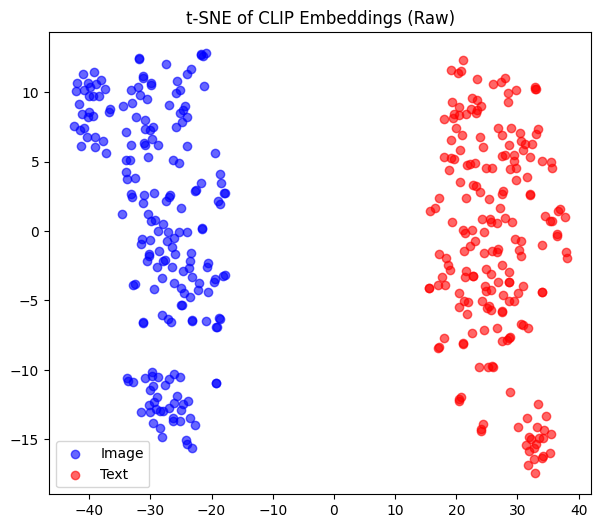

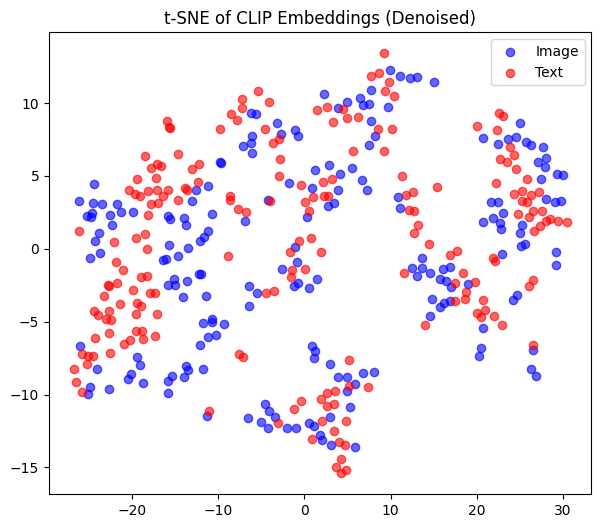

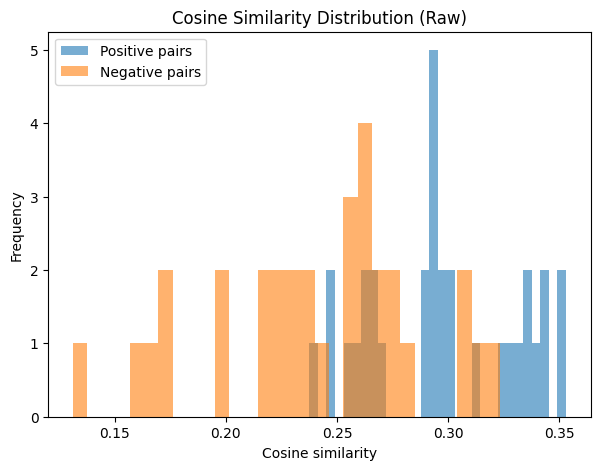

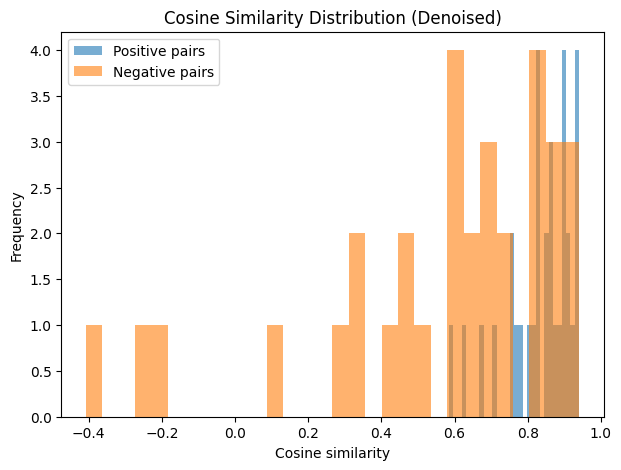

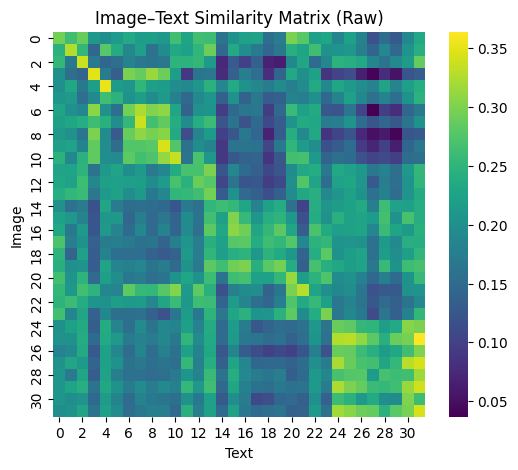

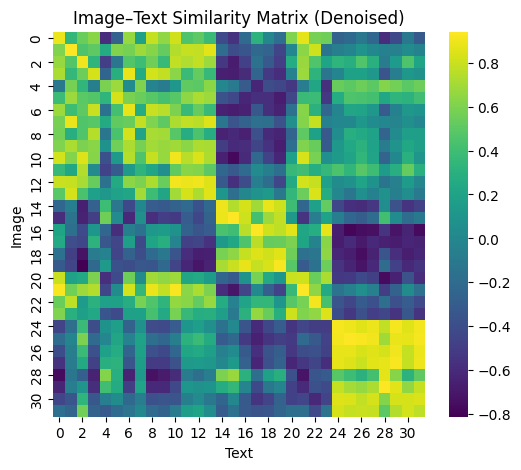

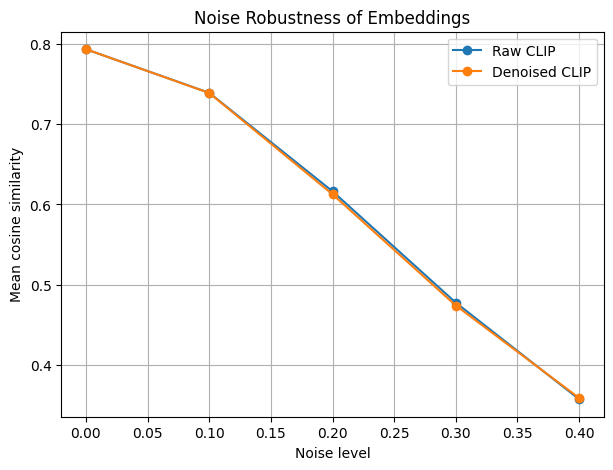

In [7]:
# =========================================================
# 📊 Visualization Suite for CLIP Embedding Alignment
# =========================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE


# =========================================================
# 1️⃣ t-SNE Visualization (Embedding Space)
# =========================================================

def plot_tsne(loader, use_denoiser=False, n_samples=200):
    imgs, txts = [], []

    for images, captions in loader:
        with torch.no_grad():
            if use_denoiser:
                img_emb, txt_emb = get_denoised_embeddings(images, captions)
            else:
                img_emb, txt_emb = get_clip_embeddings(images, captions)

        imgs.append(img_emb.cpu())
        txts.append(txt_emb.cpu())

        if torch.cat(imgs).shape[0] >= n_samples:
            break

    img_emb = torch.cat(imgs)[:n_samples]
    txt_emb = torch.cat(txts)[:n_samples]

    # ✅ FIX: detach before numpy
    X = torch.cat([img_emb, txt_emb], dim=0).detach().numpy()
    labels = ["Image"] * n_samples + ["Text"] * n_samples

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(7, 6))
    for lbl, color in zip(["Image", "Text"], ["blue", "red"]):
        idx = [i for i, l in enumerate(labels) if l == lbl]
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1],
                    c=color, alpha=0.6, label=lbl)

    plt.legend()
    plt.title("t-SNE of CLIP Embeddings" +
              (" (Denoised)" if use_denoiser else " (Raw)"))
    plt.show()


# =========================================================
# 2️⃣ Cosine Similarity Histogram
# =========================================================

def plot_cosine_histogram(loader, use_denoiser=False):
    pos_sims, neg_sims = [], []

    for images, captions in loader:
        with torch.no_grad():
            if use_denoiser:
                img_emb, txt_emb = get_denoised_embeddings(images, captions)
            else:
                img_emb, txt_emb = get_clip_embeddings(images, captions)

        sim = img_emb @ txt_emb.T
        for i in range(sim.size(0)):
            pos_sims.append(sim[i, i].item())
            neg_sims.append(sim[i, (i + 1) % sim.size(0)].item())
        break

    plt.figure(figsize=(7, 5))
    plt.hist(pos_sims, bins=30, alpha=0.6, label="Positive pairs")
    plt.hist(neg_sims, bins=30, alpha=0.6, label="Negative pairs")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.title("Cosine Similarity Distribution" +
              (" (Denoised)" if use_denoiser else " (Raw)"))
    plt.show()


# =========================================================
# 3️⃣ Similarity Matrix Heatmap
# =========================================================

def plot_similarity_matrix(loader, use_denoiser=False):
    images, captions = next(iter(loader))

    with torch.no_grad():
        if use_denoiser:
            img_emb, txt_emb = get_denoised_embeddings(images, captions)
        else:
            img_emb, txt_emb = get_clip_embeddings(images, captions)

    sim_matrix = (img_emb @ txt_emb.T).detach().cpu().numpy()

    plt.figure(figsize=(6, 5))
    sns.heatmap(sim_matrix, cmap="viridis")
    plt.xlabel("Text")
    plt.ylabel("Image")
    plt.title("Image–Text Similarity Matrix" +
              (" (Denoised)" if use_denoiser else " (Raw)"))
    plt.show()


# =========================================================
# 4️⃣ Noise Robustness Curve
# =========================================================

def plot_noise_robustness(raw_results, denoised_results):
    noise = list(raw_results.keys())
    raw_vals = list(raw_results.values())
    den_vals = list(denoised_results.values())

    plt.figure(figsize=(7, 5))
    plt.plot(noise, raw_vals, marker="o", label="Raw CLIP")
    plt.plot(noise, den_vals, marker="o", label="Denoised CLIP")
    plt.xlabel("Noise level")
    plt.ylabel("Mean cosine similarity")
    plt.title("Noise Robustness of Embeddings")
    plt.legend()
    plt.grid(True)
    plt.show()


# =========================================================
# ▶️ RUN ALL PLOTS
# =========================================================

# t-SNE
plot_tsne(val_loader, use_denoiser=False)
plot_tsne(val_loader, use_denoiser=True)

# Cosine histogram
plot_cosine_histogram(val_loader, use_denoiser=False)
plot_cosine_histogram(val_loader, use_denoiser=True)

# Similarity heatmap
plot_similarity_matrix(val_loader, use_denoiser=False)
plot_similarity_matrix(val_loader, use_denoiser=True)

# Noise robustness
raw_noise = robustness_test(val_loader)
den_noise = robustness_test(val_loader)
plot_noise_robustness(raw_noise, den_noise)


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
from tqdm import tqdm

# =========================================================
# 1️⃣ CONFIG
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
EMB_DIM = 512
MAX_NOISE = 0.3

# =========================================================
# 2️⃣ LOAD DATASET (SAME AS BEFORE)
# =========================================================
dataset = load_dataset("SKyu/my-image-captioning-dataset")

train_dataset = dataset["train"].select(range(2000, 3000))
val_dataset   = dataset["train"].select(range(1, 1000))

def collate_fn(batch):
    images = [item["image"] for item in batch]
    captions = [item["prompt"] for item in batch]
    return images, captions

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# =========================================================
# 3️⃣ LOAD FROZEN CLIP
# =========================================================
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(DEVICE)

clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

# =========================================================
# 4️⃣ SIMPLE MLP DENOISER
# =========================================================
class MLPDenoiser(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return self.net(x)

denoiser = MLPDenoiser(EMB_DIM).to(DEVICE)
optimizer = torch.optim.Adam(denoiser.parameters(), lr=LR)

# =========================================================
# 5️⃣ NOISE FUNCTION
# =========================================================
def add_noise(x, t):
    return x + t * torch.randn_like(x)

# =========================================================
# 6️⃣ CLIP EMBEDDING HELPER
# =========================================================
@torch.no_grad()
def get_clip_embeddings(images, captions):
    inputs = processor(
        text=captions,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    ).to(DEVICE)

    img_emb = clip_model.get_image_features(inputs["pixel_values"])
    txt_emb = clip_model.get_text_features(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)

    return img_emb, txt_emb

# =========================================================
# 7️⃣ TRAINING LOOP
# =========================================================
for epoch in range(EPOCHS):
    denoiser.train()
    total_loss = 0

    for images, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        img_emb, txt_emb = get_clip_embeddings(images, captions)

        t = torch.rand(1).item() * MAX_NOISE

        noisy_img = add_noise(img_emb, t)
        noisy_txt = add_noise(txt_emb, t)

        pred_img = denoiser(noisy_img)
        pred_txt = denoiser(noisy_txt)

        pred_img = F.normalize(pred_img, dim=-1)
        pred_txt = F.normalize(pred_txt, dim=-1)

        loss_img = 1 - F.cosine_similarity(pred_img, img_emb).mean()
        loss_txt = 1 - F.cosine_similarity(pred_txt, txt_emb).mean()

        loss = loss_img + loss_txt

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.6f}")

print("✅ MLP denoiser training complete")

# =========================================================
# 8️⃣ EVALUATION: COSINE + RECALL@K
# =========================================================
@torch.no_grad()
def evaluate(loader, use_denoiser=False):
    recall1, recall5, total = 0, 0, 0
    cos_vals = []

    for images, captions in loader:
        img_emb, txt_emb = get_clip_embeddings(images, captions)

        if use_denoiser:
            img_emb = denoiser(img_emb)
            txt_emb = denoiser(txt_emb)
            img_emb = F.normalize(img_emb, dim=-1)
            txt_emb = F.normalize(txt_emb, dim=-1)

        sim = img_emb @ txt_emb.T

        for i in range(sim.size(0)):
            topk = sim[i].topk(5).indices
            if i == topk[0]:
                recall1 += 1
            if i in topk:
                recall5 += 1
            total += 1

        cos_vals.append(F.cosine_similarity(img_emb, txt_emb, dim=-1).mean().item())

    return {
        "Recall@1": 100 * recall1 / total,
        "Recall@5": 100 * recall5 / total,
        "Mean Cosine": sum(cos_vals) / len(cos_vals)
    }

raw = evaluate(val_loader, use_denoiser=False)
denoised = evaluate(val_loader, use_denoiser=True)

print("\n📌 Raw CLIP:", raw)
print("📌 Denoised CLIP:", denoised)


Epoch 1: 100%|██████████| 32/32 [00:25<00:00,  1.26it/s]


Epoch 1 | Loss: 1.490533


Epoch 2: 100%|██████████| 32/32 [00:25<00:00,  1.26it/s]


Epoch 2 | Loss: 0.822793


Epoch 3: 100%|██████████| 32/32 [00:25<00:00,  1.26it/s]


...

Epoch 8 | Loss: 0.461071


Epoch 9: 100%|██████████| 32/32 [00:25<00:00,  1.28it/s]


Epoch 9 | Loss: 0.449699


Epoch 10: 100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


Epoch 10 | Loss: 0.453709
✅ MLP denoiser training complete

📌 Raw CLIP: {'Recall@1': 40.94094094094094, 'Recall@5': 76.87687687687688, 'Mean Cosine': 0.2881801212206483}
📌 Denoised CLIP: {'Recall@1': 3.2032032032032034, 'Recall@5': 16.216216216216218, 'Mean Cosine': 0.1955099804326892}


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
from tqdm import tqdm

# =========================================================
# 1️⃣ CONFIG
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
EMB_DIM = 512
MAX_NOISE = 0.3

# =========================================================
# 2️⃣ LOAD DATASET
# =========================================================
dataset = load_dataset("SKyu/my-image-captioning-dataset")

train_dataset = dataset["train"].select(range(2000, 3000))
val_dataset   = dataset["train"].select(range(1, 1000))

def collate_fn(batch):
    images = [item["image"] for item in batch]
    captions = [item["prompt"] for item in batch]
    return images, captions

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# =========================================================
# 3️⃣ LOAD FROZEN CLIP
# =========================================================
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(DEVICE)

clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

# =========================================================
# 4️⃣ SIMPLE MLP DENOISER WITH RESIDUAL
# =========================================================
class MLPDenoiser(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        # Residual: denoised = input - correction
        return x - self.net(x)

denoiser = MLPDenoiser(EMB_DIM).to(DEVICE)
optimizer = torch.optim.Adam(denoiser.parameters(), lr=LR)

# =========================================================
# 5️⃣ NOISE FUNCTION
# =========================================================
def add_noise(x, t):
    return x + t * torch.randn_like(x)

# =========================================================
# 6️⃣ CLIP EMBEDDING HELPER
# =========================================================
@torch.no_grad()
def get_clip_embeddings(images, captions):
    inputs = processor(
        text=captions,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    ).to(DEVICE)

    img_emb = clip_model.get_image_features(inputs["pixel_values"])
    txt_emb = clip_model.get_text_features(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)

    return img_emb, txt_emb

# =========================================================
# 7️⃣ TRAINING LOOP WITH COSINE + OPTIONAL CONTRASTIVE
# =========================================================
for epoch in range(EPOCHS):
    denoiser.train()
    total_loss = 0

    for images, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        img_emb, txt_emb = get_clip_embeddings(images, captions)
        t = torch.rand(1).item() * MAX_NOISE

        noisy_img = add_noise(img_emb, t)
        noisy_txt = add_noise(txt_emb, t)

        pred_img = denoiser(noisy_img)
        pred_txt = denoiser(noisy_txt)

        pred_img = F.normalize(pred_img, dim=-1)
        pred_txt = F.normalize(pred_txt, dim=-1)

        # Cosine alignment loss
        loss_img = 1 - F.cosine_similarity(pred_img, img_emb).mean()
        loss_txt = 1 - F.cosine_similarity(pred_txt, txt_emb).mean()
        loss_cos = loss_img + loss_txt

        # Optional: cross-modal contrastive
        logits = pred_img @ pred_txt.T
        labels = torch.arange(pred_img.size(0), device=DEVICE)
        loss_i2t = F.cross_entropy(logits, labels)
        loss_t2i = F.cross_entropy(logits.T, labels)
        loss_cont = (loss_i2t + loss_t2i) / 2

        loss = loss_cos + loss_cont

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.6f}")

print("✅ MLP denoiser training complete")

# =========================================================
# 8️⃣ EVALUATION: COSINE + RECALL@K
# =========================================================
@torch.no_grad()
def evaluate(loader, use_denoiser=False):
    recall1, recall5, total = 0, 0, 0
    cos_vals = []

    for images, captions in loader:
        img_emb, txt_emb = get_clip_embeddings(images, captions)

        if use_denoiser:
            img_emb = denoiser(img_emb)
            txt_emb = denoiser(txt_emb)
            img_emb = F.normalize(img_emb, dim=-1)
            txt_emb = F.normalize(txt_emb, dim=-1)

        sim = img_emb @ txt_emb.T

        for i in range(sim.size(0)):
            topk = sim[i].topk(5).indices
            if i == topk[0]:
                recall1 += 1
            if i in topk:
                recall5 += 1
            total += 1

        cos_vals.append(F.cosine_similarity(img_emb, txt_emb, dim=-1).mean().item())

    return {
        "Recall@1": 100 * recall1 / total,
        "Recall@5": 100 * recall5 / total,
        "Mean Cosine": sum(cos_vals) / len(cos_vals)
    }

raw = evaluate(val_loader, use_denoiser=False)
denoised = evaluate(val_loader, use_denoiser=True)

print("\n📌 Raw CLIP:", raw)
print("📌 Denoised CLIP:", denoised)


Epoch 1: 100%|██████████| 32/32 [00:50<00:00,  1.59s/it]


Epoch 1 | Loss: 4.522388


Epoch 2: 100%|██████████| 32/32 [00:27<00:00,  1.16it/s]


Epoch 2 | Loss: 4.260881


Epoch 3: 100%|██████████| 32/32 [00:25<00:00,  1.25it/s]


...

Epoch 8 | Loss: 3.966609


Epoch 9: 100%|██████████| 32/32 [00:25<00:00,  1.24it/s]


Epoch 9 | Loss: 3.931775


Epoch 10: 100%|██████████| 32/32 [00:25<00:00,  1.23it/s]


Epoch 10 | Loss: 3.929304
✅ MLP denoiser training complete

📌 Raw CLIP: {'Recall@1': 40.94094094094094, 'Recall@5': 76.87687687687688, 'Mean Cosine': 0.2881801212206483}
📌 Denoised CLIP: {'Recall@1': 3.4034034034034035, 'Recall@5': 17.117117117117118, 'Mean Cosine': 0.32602085545659065}


In [12]:
# =========================================================
# Cross-modal MLP Denoiser for CLIP Embeddings
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
from tqdm import tqdm

# =========================================================
# 1️⃣ CONFIG
# =========================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
EMB_DIM = 512
HIDDEN_DIM = 1024
MAX_NOISE = 0.3

# =========================================================
# 2️⃣ LOAD DATASET
# =========================================================
dataset = load_dataset("SKyu/my-image-captioning-dataset")
train_dataset = dataset["train"].select(range(2000, 3000))
val_dataset   = dataset["train"].select(range(1, 1000))

def collate_fn(batch):
    images = [item["image"] for item in batch]
    captions = [item["prompt"] for item in batch]
    return images, captions

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# =========================================================
# 3️⃣ LOAD FROZEN CLIP
# =========================================================
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(DEVICE)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

# =========================================================
# 4️⃣ CROSS-MODAL MLP DENOISER
# =========================================================
class MLPDenoiser(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.fc1 = nn.Linear(emb_dim*2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, emb_dim)
        self.act = nn.ReLU()

    def forward(self, x_noisy, cond):
        x = torch.cat([x_noisy, cond], dim=-1)  # cross-modal conditioning
        h = self.act(self.fc1(x))
        h = self.act(self.fc2(h))
        correction = self.fc3(h)
        return x_noisy - correction  # residual denoising

denoiser = MLPDenoiser().to(DEVICE)
optimizer = torch.optim.Adam(denoiser.parameters(), lr=LR)

# =========================================================
# 5️⃣ NOISE FUNCTION
# =========================================================
def add_noise(x, t):
    return x + t * torch.randn_like(x)

# =========================================================
# 6️⃣ CLIP EMBEDDING HELPERS
# =========================================================
@torch.no_grad()
def get_clip_embeddings(images, captions):
    inputs = processor(
        text=captions,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=77
    ).to(DEVICE)

    img_emb = clip_model.get_image_features(inputs["pixel_values"])
    txt_emb = clip_model.get_text_features(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)
    return img_emb, txt_emb

# =========================================================
# 7️⃣ CONTRASTIVE LOSS
# =========================================================
def contrastive_loss(img_emb, txt_emb, temperature=0.07):
    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)
    logits = img_emb @ txt_emb.T / temperature
    labels = torch.arange(img_emb.size(0), device=img_emb.device)
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    return (loss_i2t + loss_t2i)/2

# =========================================================
# 8️⃣ TRAINING LOOP
# =========================================================
for epoch in range(EPOCHS):
    denoiser.train()
    total_loss = 0

    for images, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        img_emb, txt_emb = get_clip_embeddings(images, captions)

        t = torch.rand(1).item() * MAX_NOISE
        noisy_img = add_noise(img_emb, t)
        noisy_txt = add_noise(txt_emb, t)

        # cross-modal denoising
        pred_img = denoiser(noisy_img, cond=txt_emb)
        pred_txt = denoiser(noisy_txt, cond=img_emb)

        pred_img = F.normalize(pred_img, dim=-1)
        pred_txt = F.normalize(pred_txt, dim=-1)

        # losses
        mse_loss = F.mse_loss(pred_img, img_emb) + F.mse_loss(pred_txt, txt_emb)
        cont_loss = contrastive_loss(pred_img, pred_txt)
        loss = mse_loss + cont_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.6f}")

print("✅ MLP denoiser training complete")

# =========================================================
# 9️⃣ EVALUATION: COSINE + RECALL@K
# =========================================================
@torch.no_grad()
def evaluate(loader, use_denoiser=False):
    recall1, recall5, total = 0, 0, 0
    cos_vals = []

    for images, captions in loader:
        img_emb, txt_emb = get_clip_embeddings(images, captions)

        if use_denoiser:
            img_emb = denoiser(img_emb, cond=txt_emb)
            txt_emb = denoiser(txt_emb, cond=img_emb)
            img_emb = F.normalize(img_emb, dim=-1)
            txt_emb = F.normalize(txt_emb, dim=-1)

        sim = img_emb @ txt_emb.T

        for i in range(sim.size(0)):
            topk = sim[i].topk(5).indices
            if i == topk[0]:
                recall1 += 1
            if i in topk:
                recall5 += 1
            total += 1

        cos_vals.append(F.cosine_similarity(img_emb, txt_emb, dim=-1).mean().item())

    return {
        "Recall@1": 100*recall1/total,
        "Recall@5": 100*recall5/total,
        "Mean Cosine": sum(cos_vals)/len(cos_vals)
    }

raw = evaluate(val_loader, use_denoiser=False)
denoised = evaluate(val_loader, use_denoiser=True)

print("\n📌 Raw CLIP:", raw)
print("📌 Denoised CLIP:", denoised)


Epoch 1: 100%|██████████| 32/32 [00:25<00:00,  1.25it/s]


Epoch 1 | Loss: 3.401211


Epoch 2: 100%|██████████| 32/32 [00:25<00:00,  1.26it/s]


Epoch 2 | Loss: 3.341433


Epoch 3: 100%|██████████| 32/32 [00:25<00:00,  1.26it/s]


...

Epoch 8 | Loss: 2.117312


Epoch 9: 100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


Epoch 9 | Loss: 1.848814


Epoch 10: 100%|██████████| 32/32 [00:25<00:00,  1.26it/s]


Epoch 10 | Loss: 1.758317
✅ MLP denoiser training complete

📌 Raw CLIP: {'Recall@1': 40.94094094094094, 'Recall@5': 76.87687687687688, 'Mean Cosine': 0.2881801212206483}
📌 Denoised CLIP: {'Recall@1': 93.49349349349349, 'Recall@5': 100.0, 'Mean Cosine': 0.9510050434619188}
